 # Task 6: K-Nearest Neighbors (KNN) Classification

 1.Choose a classification dataset and normalize features.

 2.Use KNeighborsClassifier from sklearn.

 3.Experiment with different values of K.

 4.Evaluate model using accuracy,
 confusion matrix.

 5.Visualize decision boundaries.

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Data Loading

In [2]:
df = pd.read_csv('Iris.csv')

In [3]:
print("\nData shape:\n", df.shape)


Data shape:
 (150, 6)


In [4]:
display(df.head())
display(df.info())
display(df.describe())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


None

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


# Data Exploration

In [5]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [6]:
print("\nTarget variable distribution:\n", df['Species'].value_counts())


Target variable distribution:
 Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


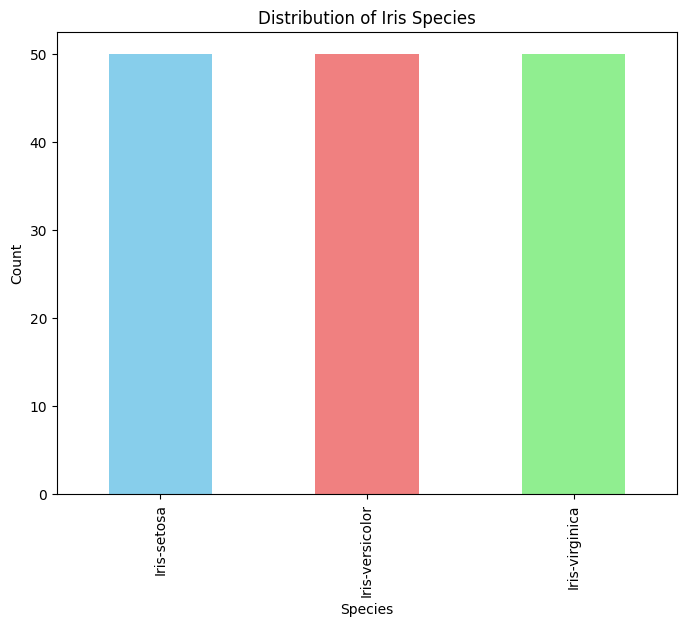

In [7]:
df['Species'].value_counts().plot(kind='bar', figsize=(8, 6), color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

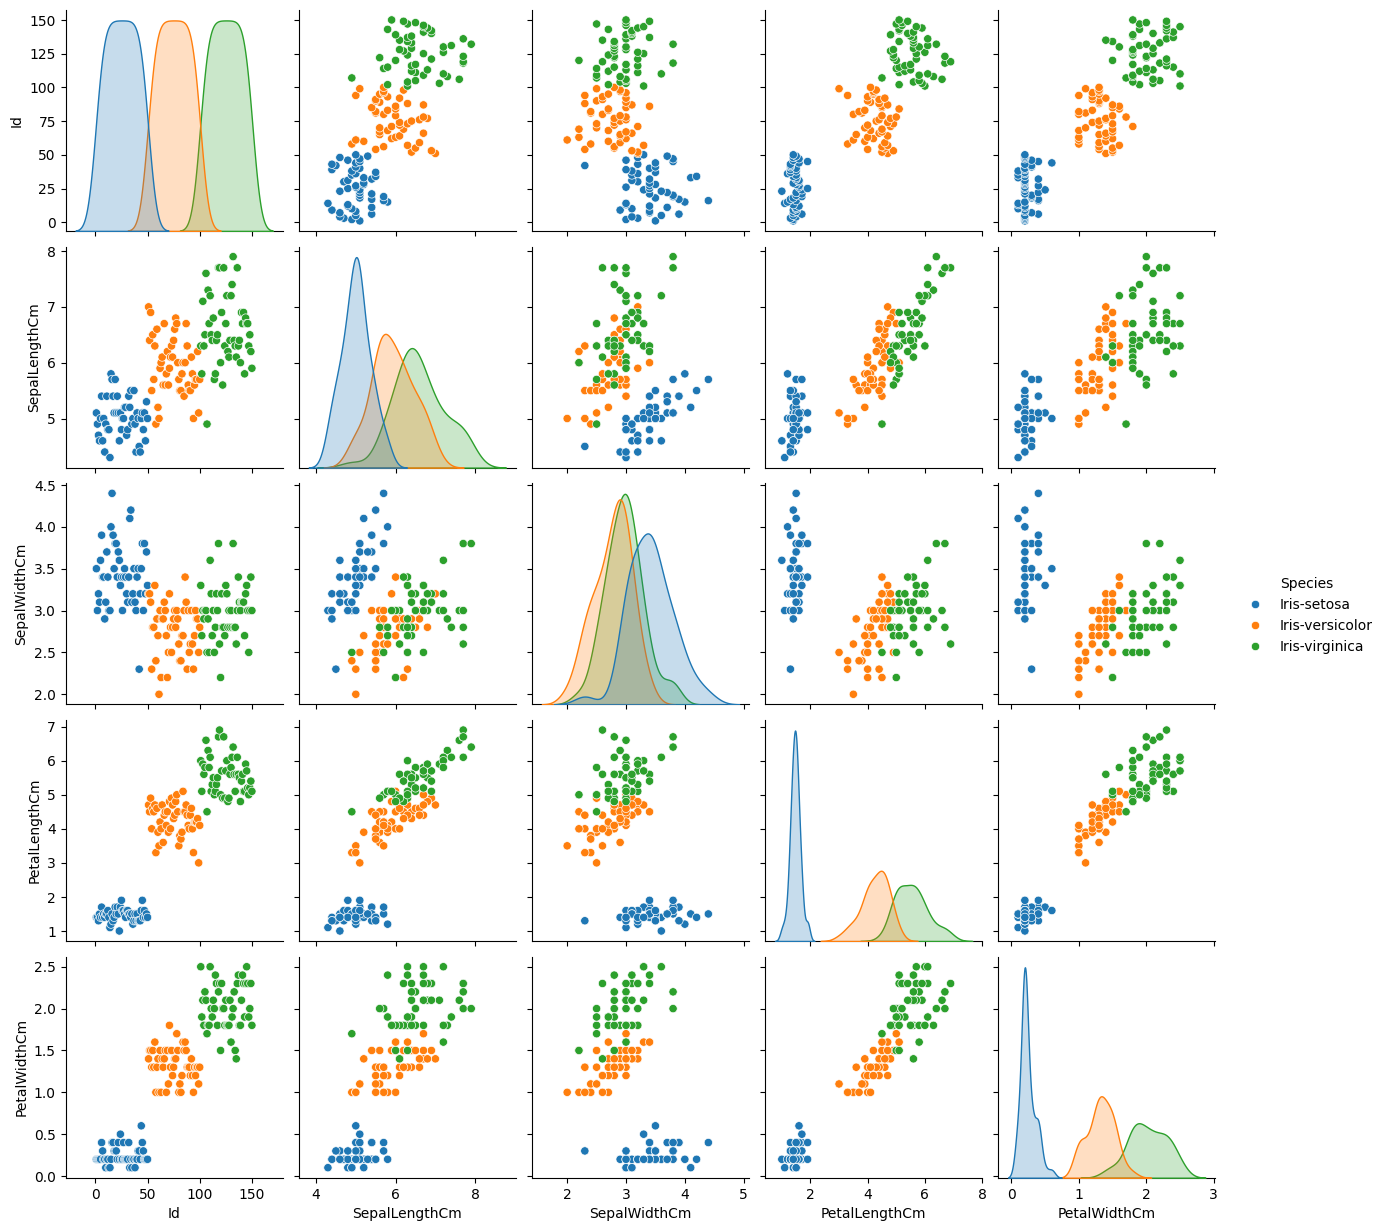

In [8]:
sns.pairplot(df, hue='Species', diag_kind='kde')
plt.show()

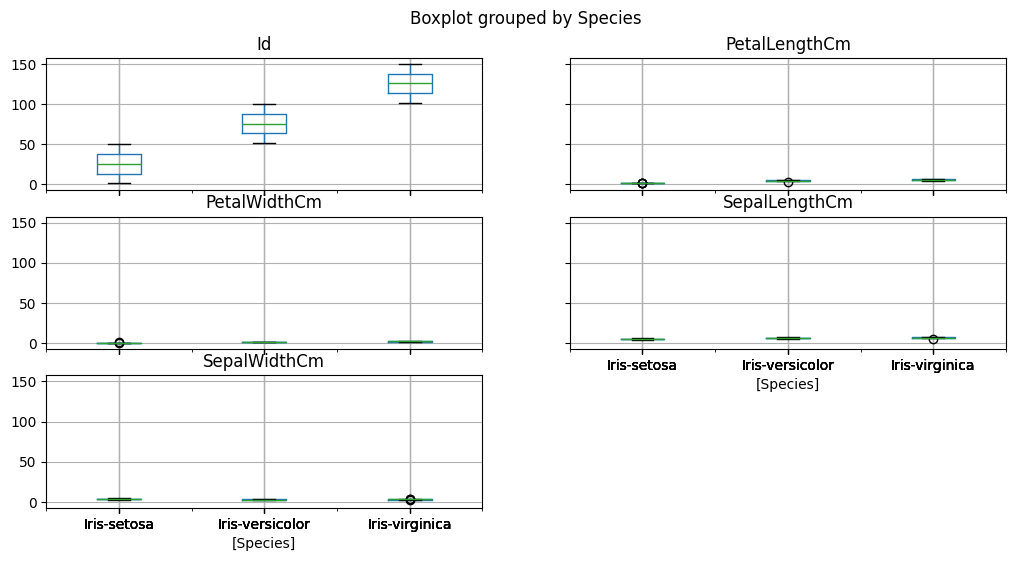

In [9]:
df.boxplot(by='Species', figsize=(12, 6))
plt.show()

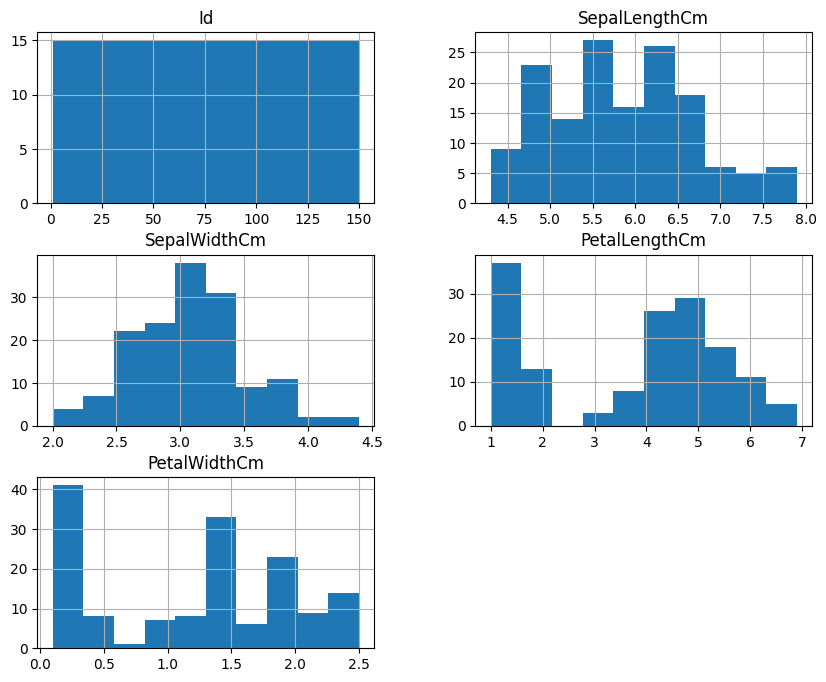

In [10]:
df.hist(figsize=(10, 8))
plt.show()

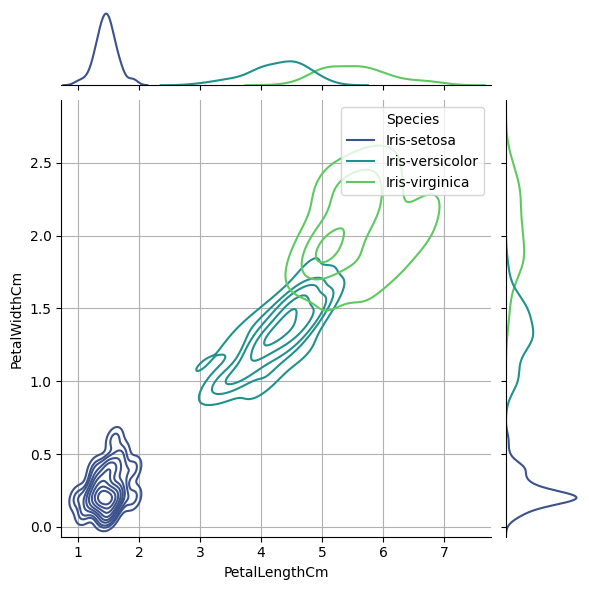

In [11]:
sns.jointplot(x="PetalLengthCm", y="PetalWidthCm", hue='Species', data=df, kind="kde", palette='viridis') # Changed 'species' to 'Species' for hue
plt.grid()
plt.show()

<Figure size 1000x800 with 0 Axes>

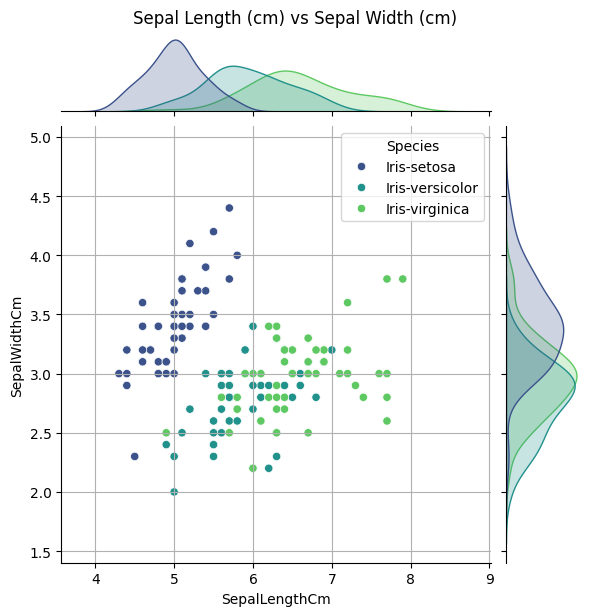

In [12]:
plt.figure(figsize=(10, 8))
sns.jointplot(data=df, x='SepalLengthCm', y='SepalWidthCm',
              hue='Species', kind='scatter', palette = 'viridis')
plt.suptitle('Sepal Length (cm) vs Sepal Width (cm)', y=1.02)
plt.grid()
plt.show()

<Figure size 1000x800 with 0 Axes>

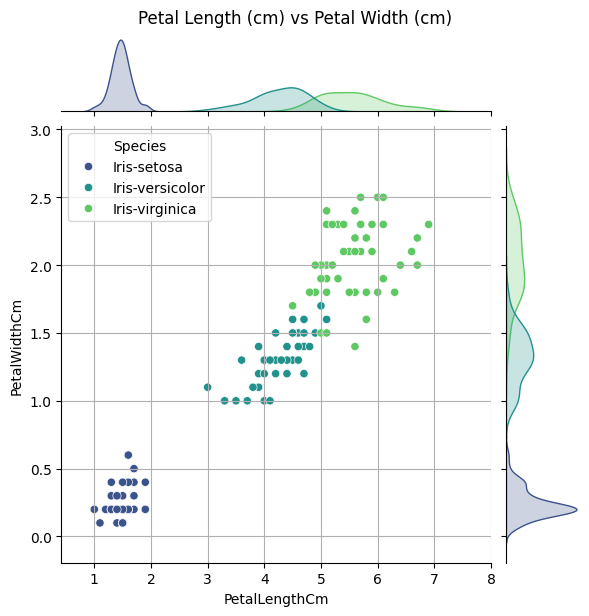

In [13]:
plt.figure(figsize=(10, 8))
sns.jointplot(data=df, x='PetalLengthCm', y='PetalWidthCm',
              hue='Species', kind='scatter', palette='viridis')
plt.suptitle('Petal Length (cm) vs Petal Width (cm)', y=1.02)
plt.grid()
plt.show()

# Data Preparation

In [14]:
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

In [15]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Data Splitting

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print("X_train shape    :", X_train.shape)
print("X_test shape     :", X_test.shape)
print("y_train shape    :", y_train.shape)
print("y_test shape     :", y_test.shape)

X_train shape    : (105, 4)
X_test shape     : (45, 4)
y_train shape    : (105,)
y_test shape     : (45,)


# Model Training

In [17]:
k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9]

knn_classifiers = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    knn_classifiers[k] = knn

# Model Evalution

In [18]:
results = {}

for k, knn in knn_classifiers.items():
    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    results[k] = {
        'accuracy': accuracy,
        'confusion_matrix': conf_matrix
    }

    print(f"Results for K = {k}:")
    print(f"Accuracy           : {accuracy}")
    print(f"Confusion Matrix   :\n{conf_matrix}\n")

Results for K = 1:
Accuracy           : 1.0
Confusion Matrix   :
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Results for K = 2:
Accuracy           : 1.0
Confusion Matrix   :
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Results for K = 3:
Accuracy           : 1.0
Confusion Matrix   :
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Results for K = 4:
Accuracy           : 1.0
Confusion Matrix   :
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Results for K = 5:
Accuracy           : 1.0
Confusion Matrix   :
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Results for K = 6:
Accuracy           : 1.0
Confusion Matrix   :
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Results for K = 7:
Accuracy           : 1.0
Confusion Matrix   :
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Results for K = 8:
Accuracy           : 1.0
Confusion Matrix   :
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Results for K = 9:
Accuracy           : 1.0
Confusion Matrix   :
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]



In [19]:

best_k = max(results, key=lambda k: results[k]['accuracy'])
print(f"The best K value is {best_k} with an accuracy of {results[best_k]['accuracy']}")

The best K value is 1 with an accuracy of 1.0


# Data Visualization

The best k value is 1 with an accuracy of 1.0


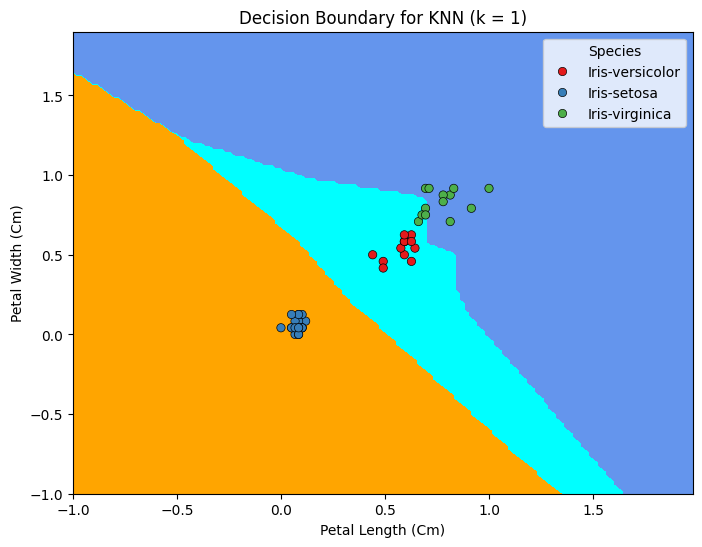

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder


best_k = max(results, key=lambda k: results[k]['accuracy'])
print(f"The best k value is {best_k} with an accuracy of {results[best_k]['accuracy']}")

models = {}
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    models[k] = knn

best_model = models[best_k]


X_test_vis = X_test

h = .02
x_min, x_max = X_test_vis[:, 2].min() - 1, X_test_vis[:, 2].max() + 1
y_min, y_max = X_test_vis[:, 3].min() - 1, X_test_vis[:, 3].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

dummy_sepal_length = np.full(xx.ravel().shape, np.mean(X_test_vis[:, 0]))
dummy_sepal_width = np.full(yy.ravel().shape, np.mean(X_test_vis[:, 1]))
Z = best_model.predict(np.c_[dummy_sepal_length, dummy_sepal_width, xx.ravel(), yy.ravel()])

le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)
Z_encoded = le.transform(Z)
Z = Z_encoded.reshape(xx.shape)

cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=cmap_light)

sns.scatterplot(x=X_test_vis[:, 2], y=X_test_vis[:, 3], hue=y_test, palette="Set1", alpha=1.0, edgecolor="black")

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel("Petal Length (Cm)")
plt.ylabel("Petal Width (Cm)")
plt.title(f"Decision Boundary for KNN (k = {best_k})")
plt.show()